In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import torch
from hydra.utils import instantiate
from hydra import initialize, compose
import hydra
import wandb

from model.modelCreator import ModelCreator
from omegaconf import OmegaConf
from scripts.run import setup_model
from data.dataManager import DataManagerLayersShowers, DataManagerLayers
from datetime import datetime
from utils.HLF.atlasgeo import evaluate_and_plot
from utils.optimization.plots import ShowerPlotter
from utils.optimization.scalar_metrics import ScalarMetricCalculator
from utils.displays.shower_plots import visualize_sliced_distribution, visualize_tail_events_comparison, visualize_tail_hits_comparison
import os
from model.rbm.rbm_two_partite import RBM_TwoPartite
from scripts.run_transfusion import setup_model as setup_model_transfusion
import copy
from data.layers import transform_dataset
from scripts.RBM_2P_MNIST import save_clamped_samples_for_vae
from utils.rbm.rbm_utils import save_clamped_PTT_samples, prepare_ptt_checkpoints
from utils.rbm.rbm_plots import plot_weight_distribution
from utils.dwave.postprocessing import load_qpu_samples




/usr/local/lib/python3.12/dist-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (6.0.0.post1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(
[20:15:48.761] INFO   CaloQuVAE                                         Loading configuration.
[20:15:50.269] INFO   numexpr.utils                                     Note: detected 96 virtual cores but NumExpr set to maximum of 64, check "NUMEXPR_MAX_THREADS" environment variable.
[20:15:50.270] INFO   numexpr.utils                                     Note: NumExpr detected 96 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 16.
[20:15:50.270] INFO   numexpr.utils                                     NumExpr defaulting to 16 threads.


In [2]:
hydra.core.global_hydra.GlobalHydra.instance().clear()
initialize(version_base=None, config_path="config")
cfg=compose(config_name="config_layers.yaml")
# cfg=compose(config_name="config.yaml")
wandb.init(tags = [cfg.data.dataset_name], project=cfg.wandb.project, entity=cfg.wandb.entity, config=OmegaConf.to_container(cfg, resolve=True), mode='disabled')

In [3]:
new_model = False
if new_model:
    self = (cfg)
else:
    config = OmegaConf.load(cfg.config_path)
    config.gpu_list = cfg.gpu_list
    config.load_state = 1
    self = setup_model(config)
    self._model_creator.load_state(config.run_path, self.device)
    self.data_mgr.apply_stats_and_build_loaders(
        self.model.feature_min.cpu(), 
        self.model.feature_max.cpu()
    )


[20:15:53.136] INFO   data.dataManager                                  Loading ATLAS Layer+Showers dataset: AtlasCustom2
[20:15:56.604] INFO   model.modelCreator                                ::Creating Model
[20:15:56.607] INFO   model.autoencoder.autoencoderbase                 Using smoothing_dist: gumbel
[20:16:12.866] INFO   scripts.run                                       Requesting GPUs. GPU list :[2]
[20:16:12.868] INFO   scripts.run                                       Main GPU : cuda:2
[20:16:13.142] INFO   engine.engine                                     Using separate beta annealing: beta_latent starts at 1.0, beta_hits starts at 1.0
[20:16:28.118] INFO   model.modelCreator                                Loading state
[20:16:28.198] INFO   model.modelCreator                                Loading weights from file : /fast_scratch_1/caloqvae/lzhu/wandb/run-20260421_001607-k6wwwxh4/files/ae_layers_no_hits_best_ema_epoch33.pth
[20:16:28.199] INFO   model.modelCreator     

In [4]:
rbm_cfg=compose(config_name="config_layers.yaml")
dummy_data = torch.zeros(1, rbm_cfg.rbm.num_visible_nodes).to(self.device)
# CHECKPOINT_FILE = "/home/leozhu/CaloQuVAE/wandb-outputs/run_2026-03-31_22-41-45_RBM_TwoPartite/training_checkpoint_epoch_4000.h5"
# CHECKPOINT_FILE = " /home/leozhu/CaloQuVAE/wandb-outputs/run_2026-03-31_22-41-45_RBM_TwoPartite/training_checkpoint_epoch_4000.h5"
# CHECKPOINT_FILE = "/home/leozhu/CaloQuVAE/wandb-outputs/run_2026-04-01_23-54-05_RBM_TwoPartite/training_checkpoint_epoch_4000.h5"
# CHECKPOINT_FILE = "/home/leozhu/CaloQuVAE/wandb-outputs/run_2026-04-02_00-09-27_RBM_TwoPartite/training_checkpoint_epoch_4000.h5"
# CHECKPOINT_FILE = " /home/leozhu/CaloQuVAE/wandb-outputs/run_2026-04-02_22-31-35_RBM_TwoPartite/training_checkpoint_epoch_4000.h5"

# CHECKPOINT_FILE = "/home/leozhu/CaloQuVAE/wandb-outputs/run_2026-04-02_22-31-04_RBM_TwoPartite/training_checkpoint_epoch_4000.h5"
# CHECKPOINT_FILE = "/home/leozhu/CaloQuVAE/wandb-outputs/run_2026-04-14_20-57-02_RBM_TwoPartite/training_checkpoint_epoch_4000.h5"
# CHECKPOINT_FILE = "/home/leozhu/CaloQuVAE/wandb-outputs/run_2026-04-15_00-08-50_RBM_TwoPartite/training_checkpoint_epoch_4000.h5"
# CHECKPOINT_FILE = "/home/leozhu/CaloQuVAE/wandb-outputs/run_2026-04-15_00-09-20_RBM_TwoPartite/training_checkpoint_epoch_4000.h5"
# CHECKPOINT_FILE = "/home/leozhu/CaloQuVAE/wandb-outputs/run_2026-04-15_22-30-17_RBM_TwoPartite/training_checkpoint_epoch_4000.h5"
# CHECKPOINT_FILE = "/home/leozhu/CaloQuVAE/wandb-outputs/run_2026-04-15_22-33-23_RBM_TwoPartite/training_checkpoint_epoch_4000.h5"
# CHECKPOINT_FILE = "/home/leozhu/CaloQuVAE/wandb-outputs/run_2026-04-15_22-34-46_RBM_TwoPartite/training_checkpoint_epoch_4000.h5"
# CHECKPOINT_FILE = "/home/leozhu/CaloQuVAE/wandb-outputs/run_2026-04-17_18-48-18_RBM_MPF/training_checkpoint_epoch_4000.h5"
# CHECKPOINT_FILE = "/home/leozhu/CaloQuVAE/wandb-outputs/run_2026-04-17_18-49-28_RBM_MPF/training_checkpoint_epoch_4000.h5"
# CHECKPOINT_FILE = "/home/leozhu/CaloQuVAE/wandb-outputs/run_2026-04-17_19-14-14_RBM_MPF/training_checkpoint_epoch_4000.h5"
# CHECKPOINT_FILE = "/home/leozhu/CaloQuVAE/wandb-outputs/run_2026-04-19_05-30-28_RBM_MPF/training_checkpoint_epoch_4000.h5"
# CHECKPOINT_FILE = "/home/leozhu/CaloQuVAE/wandb-outputs/run_2026-04-19_05-30-47_RBM_MPF/training_checkpoint_epoch_4000.h5"
# CHECKPOINT_FILE = "/home/leozhu/CaloQuVAE/wandb-outputs/run_2026-04-20_20-52-54_RBM_MPF/training_checkpoint_epoch_512.h5"
# CHECKPOINT_FILE = "/home/leozhu/CaloQuVAE/wandb-outputs/run_2026-04-21_00-25-17_RBM_MPF/training_checkpoint_epoch_4000.h5"
# CHECKPOINT_FILE = "/home/leozhu/CaloQuVAE/wandb-outputs/run_2026-04-21_00-25-42_RBM_MPF/training_checkpoint_epoch_4000.h5"
# CHECKPOINT_FILE = "/home/leozhu/CaloQuVAE/wandb-outputs/run_2026-04-21_18-04-46_RBM_MPF/training_checkpoint_epoch_4000.h5"
# CHECKPOINT_FILE = "/home/leozhu/CaloQuVAE/wandb-outputs/run_2026-04-21_18-08-54_RBM_MPF/training_checkpoint_epoch_4000.h5"
# CHECKPOINT_FILE = "/home/leozhu/CaloQuVAE/wandb-outputs/run_2026-04-22_19-13-33_RBM_MPF/training_checkpoint_epoch_500.h5"
CHECKPOINT_FILE = "/home/leozhu/CaloQuVAE/wandb-outputs/run_2026-04-22_21-23-45_RBM_MPF/training_checkpoint_epoch_500.h5"
# CHECKPOINT_FILE = "/home/leozhu/CaloQuVAE/wandb-outputs/run_2026-04-22_22-18-30_RBM_MPF/training_checkpoint_epoch_4000.h5"


rbm = RBM_TwoPartite(rbm_cfg, data=dummy_data)

print(f"Instantiated RBM with {rbm.num_visible} visible units.")

# --- Step 5: Load the checkpoint ---
# This loads the saved weights, chains, and RNG state *into* the object
try:
    # Load the latest epoch (epoch=None)
    loaded_epoch = rbm.load_checkpoint(CHECKPOINT_FILE, epoch=None) 
    print(f"Successfully loaded checkpoint from epoch {loaded_epoch}.")
except Exception as e:
    print(f"Error loading checkpoint: {e}")

# --- Step 6: Access the data ---
if 'rbm' in locals():
    print("\nAccessing loaded data:")
    
    # Access parameters
    weights = rbm.params["weight_matrix"]
    vbias = rbm.params["vbias"]
    print(f"  Weight matrix shape: {weights.shape}")
    print(f"  Visible bias mean: {vbias.mean().item():.4f}")
    
    # Access persistent chains
    chains = rbm.chains["v"]
    print(f"  Persistent chains shape: {chains.shape}")

[20:16:28.447] INFO   model.rbm.rbm_two_partite                         No valid mask found. Proceeding without a weight mask.
[20:16:28.448] INFO   model.rbm.rbm_two_partite                         Initializing RBM parameters with std: 0.0001
[20:16:28.503] INFO   model.rbm.rbm_two_partite                         FPMPF gradient enabled: per-sample exp(½ΔF) reweighting with J_D·J_S scaling.
[20:16:28.506] INFO   model.rbm.rbm_two_partite                         Loading parameters from epoch_500...
[20:16:28.627] INFO   model.rbm.rbm_two_partite                         Loaded persistent chains.
[20:16:28.629] INFO   model.rbm.rbm_two_partite                         Restoring RNG states...


Instantiated RBM with 177 visible units.
Successfully loaded checkpoint from epoch 500.

Accessing loaded data:
  Weight matrix shape: torch.Size([177, 161])
  Visible bias mean: 0.2388
  Persistent chains shape: torch.Size([4990, 177])


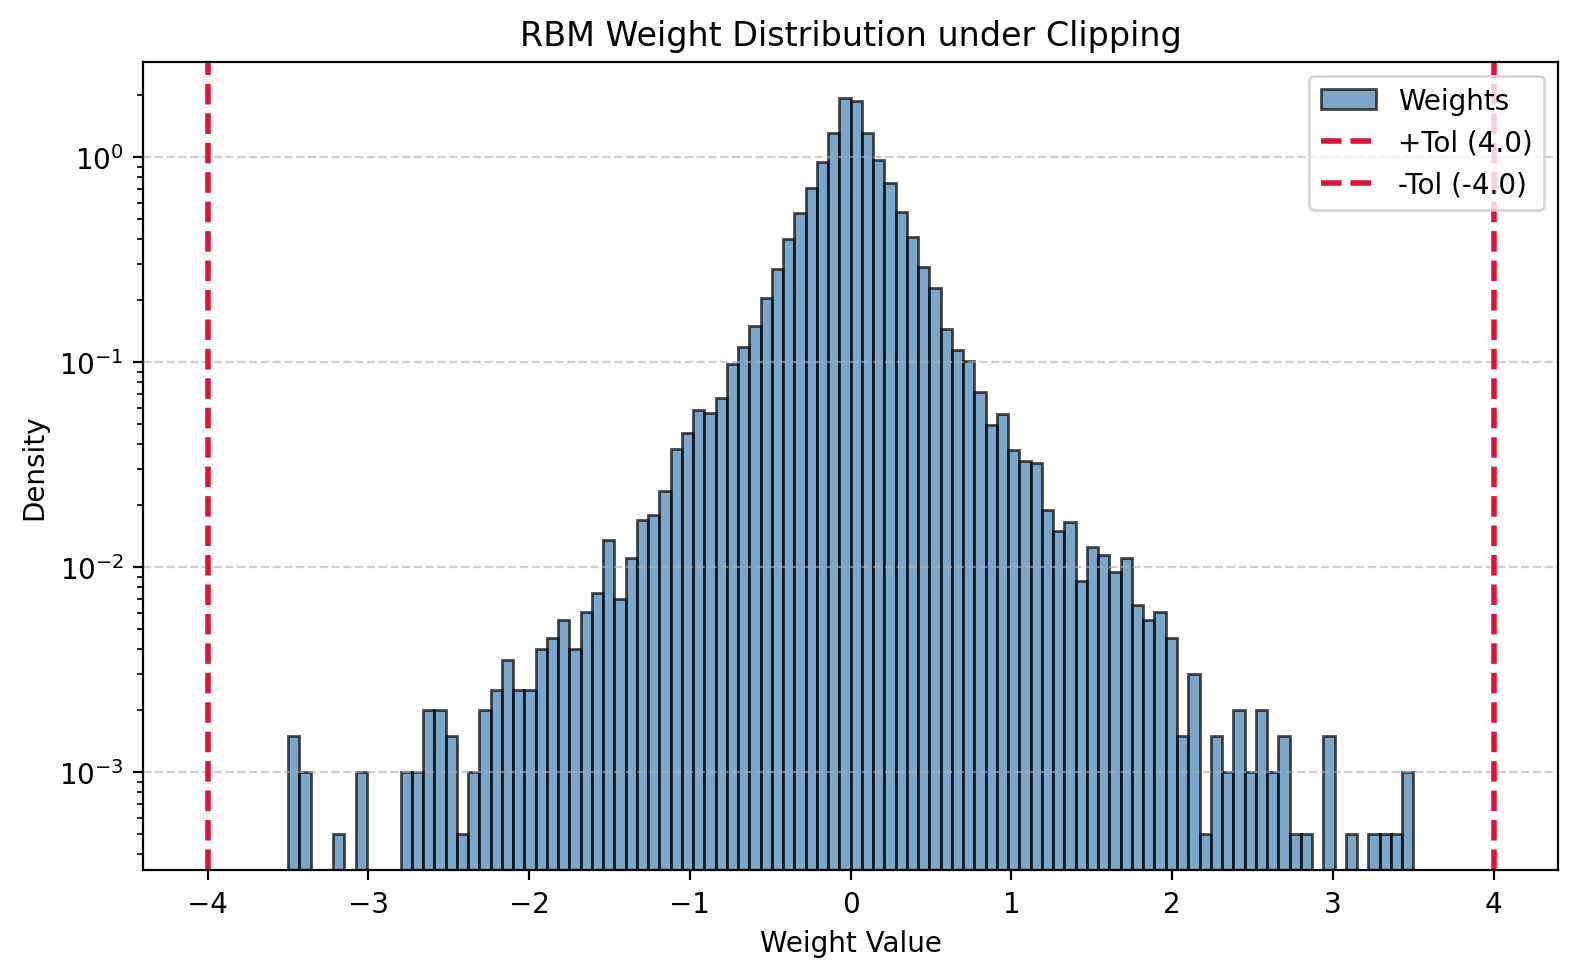

In [5]:
plot_weight_distribution(rbm, abs_tol=4.0)

In [ ]:
# 1. Load your configuration
rbm_cfg = compose(config_name="config_layers.yaml")

RUN_DIR = "/home/leozhu/CaloQuVAE/wandb-outputs/run_2026-03-31_22-41-45_RBM_TwoPartite"

# 3. Generate the chronological list of loaded models
ptt_models = prepare_ptt_checkpoints(RUN_DIR, rbm_cfg)

In [6]:
tfusion_cfg_master=compose(config_name="tfusion_config.yaml")
tfusion_cfg = OmegaConf.load(tfusion_cfg_master.config_path)
tfusion_cfg.gpu_list = cfg.gpu_list

tfusion_engine = setup_model_transfusion(tfusion_cfg)
tfusion_engine._model_creator.load_state(tfusion_cfg.run_path, tfusion_engine.device)


[20:16:29.518] INFO   data.dataManager                                  Loading ATLAS Layer dataset: AtlasCustom2
[20:16:33.791] INFO   data.dataManager                                  Using pre-calculated stratified splits: Tr=399990, Val=49994
[20:16:33.791] INFO   data.dataManager                                  Loading feature statistics from /fast_scratch_1/caloqvae/lzhu/wandb/run-20260225_231755-ubgp0yf2/files/feature_stats.pt
[20:16:33.794] INFO   data.dataManager                                  Train: 399990 events, 98 batches
[20:16:33.795] INFO   data.dataManager                                  Val: 49994 events, 13 batches
[20:16:33.796] INFO   data.dataManager                                  Test: 50016 events, 13 batches
[20:16:33.797] INFO   model.modelCreator                                ::Creating Model
[20:16:33.824] INFO   scripts.run                                       Requesting GPUs. GPU list :[2]
[20:16:33.824] INFO   scripts.run                          

Loading weights for module =  net


In [ ]:
def recover_E_samples(e_inc, u_scaled, feature_min, feature_max, f=1.60, eps=1e-7):
    """
    Inverts the min-max scaling and transform_dataset to recover raw layer energies.
    
    Args:
        e_inc: Incidence energy in MeV, shape (N, 1)
        u_scaled: Scaled u values, shape (N, 5) — after (u - min) / (max - min)
        feature_min: Min used for scaling, broadcastable to (N, 5)
        feature_max: Max used for scaling, broadcastable to (N, 5)
    Returns:
        E: Recovered raw layer energies, shape (N, 5)
    """
    # Undo min-max scaling
    u = u_scaled * (feature_max - feature_min) + feature_min

    # Recover E_tot from u0
    E_tot = u[:, 0:1] * (f * e_inc + eps)

    # Iteratively recover E0..E3 from the fraction components u1..u4
    E = torch.zeros_like(u)
    rem = E_tot
    for i in range(u.shape[1] - 1):
        E[:, i:i+1] = u[:, i+1:i+2] * rem
        rem = rem - E[:, i:i+1]

    # E4 is the remainder
    E[:, -1:] = rem
    return E

In [12]:
for validation_dataset in cfg.validation_datasets[5:6]:
    val_cfg_tfusion = copy.deepcopy(tfusion_cfg)
    val_cfg_tfusion.data = OmegaConf.load(f"config/data/{validation_dataset}.yaml")    
    val_data_manager_tfusion = DataManagerLayers(val_cfg_tfusion)
    # tfusion_engine.evaluate_tfusion(val_data_manager_tfusion.val_loader, epoch = 0, close_plots=False)

    E_samples, _, x0 = tfusion_engine.sample_tfusion(epoch=0, data_loader=val_data_manager_tfusion.val_loader)
    print(f"Sampled {E_samples.shape[0]} samples from Transfusion model for dataset {validation_dataset}.")
    u_samples = transform_dataset(E_samples, x0).to(self.device)
    u_samples = (u_samples - self.model.feature_min) / (self.model.feature_max - self.model.feature_min) # scale to [0, 1]
    self.load_cond_encoding(x0, u_samples)
    print(self.post_cond_samples.shape)
    run_timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    model_type_name = "RBM_FC"
    wandb_output_path = "/home/leozhu/CaloQuVAE/wandb-outputs"
    save_dir = os.path.join(
        wandb_output_path, f"run_{run_timestamp}_{model_type_name}_{validation_dataset}"
    )
    os.makedirs(save_dir, exist_ok=True)

    prior_samples_path = save_clamped_samples_for_vae(
    rbm,
    input_data=self.post_cond_samples,
    n_clamped=self._config.model.cond_p_size,
    gibbs_steps=5000,
    save_dir=save_dir,
    gen_batch_size=8192
    )
    rbm_samples = torch.load(prior_samples_path)
    print(rbm_samples.shape)
    classical_showers = self.generate_showers_from_rbm(rbm_samples, x0, u_samples, E_samples)


    qrbm_samples, x0_quantum, u_quantum, E_quantum= load_qpu_samples([
        "/fast_scratch_1/caloqvae/dwave_samples_apr_24/energy_250000",
        # "/fast_scratch_1/caloqvae/dwave_samples_apr_23/uniform_range",
    ])
    # E_quantum = recover_E_samples(e_inc=x0_quantum, u_scaled=u_quantum, feature_min=self.model.feature_min.cpu(), feature_max=self.model.feature_max.cpu())
    quantum_showers = self.generate_showers_from_rbm(qrbm_samples, x0_quantum, u_quantum, E_quantum)

    
    val_cfg = compose(config_name="config_layers", overrides=[f"data={validation_dataset}", f"feature_stats_path={self._config.feature_stats_path}"])    
    val_data_manager = DataManagerLayersShowers(val_cfg)
    val_data_manager.apply_stats_and_build_loaders(
        self.model.feature_min.cpu(), 
        self.model.feature_max.cpu()
    )


    self.showers_prior = classical_showers
    self.evaluate_ae(val_data_manager.val_loader, 0)
    torch.save(self.post_samples, os.path.join(save_dir, "post_samples.pt"))
    data_to_plot = {
        "GEANT4": (self.showers, x0),           # The Reference
        "Recon": (self.showers_recon, x0),     # Model 1
        "GPU":   (self.showers_prior, x0),     # Model 2
        "QPU": (quantum_showers, x0_quantum)  # Model 3
    }

    # 2. Run the pipeline
    print("shape sanity checks:", {k: v[0].shape for k, v in data_to_plot.items()})
    binning_file = val_cfg.data.binning_path
    print(binning_file)
    wandb_output_path = "/home/leozhu/CaloQuVAE/wandb-outputs"
    run_timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

    save_dir = os.path.join(
        wandb_output_path, f"plots_{run_timestamp}_{validation_dataset}_QPU_final"
    )

    evaluate_and_plot(data_to_plot, binning_file, output_dir=save_dir)
    save_dir_ranges = save_dir + "_narrow"
    scale = 10
    ranges = {
    'MeanEta': (-scale, scale),
    'WidthEta': (0, 4*scale),
    'MeanPhi': (-scale, scale),
    'WidthPhi': (0, 4*scale),
    }
    evaluate_and_plot(data_to_plot, binning_file, output_dir=save_dir_ranges, fixed_bin_ranges=ranges, num_bins=100)


[04:32:15.963] INFO   data.dataManager                                  Loading ATLAS Layer dataset: AtlasCustom250GeV
[04:32:16.116] INFO   data.dataManager                                  Using pre-calculated stratified splits: Tr=0, Val=10000
[04:32:16.117] INFO   data.dataManager                                  Loading feature statistics from /fast_scratch_1/caloqvae/lzhu/wandb/run-20260225_231755-ubgp0yf2/files/feature_stats.pt
[04:32:16.120] INFO   data.dataManager                                  Train Loader: 0 events (Skipped)
[04:32:16.121] INFO   data.dataManager                                  Val: 10000 events, 10 batches
[04:32:16.121] INFO   data.dataManager                                  Test Loader: 0 events (Skipped)
[04:32:22.882] INFO   scripts.RBM_2P_MNIST                              Attempting to generate 10000 clamped samples for VAE...
[04:32:22.884] INFO   scripts.RBM_2P_MNIST                              RBM num_chains = 4990. Using gen_batch_size = 8192

Sampled 10000 samples from Transfusion model for dataset AtlasCustom250GeV.
torch.Size([10000, 36])


[04:32:24.443] INFO   scripts.RBM_2P_MNIST                              ==================================================
[04:32:24.444] INFO   scripts.RBM_2P_MNIST                              Saved clamped samples for VAE to: /home/leozhu/CaloQuVAE/wandb-outputs/run_2026-04-27_04-32-22_RBM_FC_AtlasCustom250GeV/rbm_clamped_samples_train_data_final.pt
[04:32:24.445] INFO   scripts.RBM_2P_MNIST                              Saved dummy labels to: /home/leozhu/CaloQuVAE/wandb-outputs/run_2026-04-27_04-32-22_RBM_FC_AtlasCustom250GeV/rbm_clamped_samples_train_labels_final.pt
[04:32:24.446] INFO   scripts.RBM_2P_MNIST                              Final data shape: torch.Size([10000, 177])
[04:32:24.446] INFO   scripts.RBM_2P_MNIST                              ==================================================


torch.Size([10000, 177])
  [/fast_scratch_1/caloqvae/dwave_samples_apr_24/energy_250000] 7250 samples
Loaded 7250 samples total from /fast_scratch_1/caloqvae/dwave_samples_apr_24/energy_250000
  v: torch.Size([7250, 177])  energies: torch.Size([7250, 1])  u: torch.Size([7250, 5])  E: torch.Size([7250, 5])


[04:32:45.949] INFO   data.dataManager                                  Loading ATLAS Layer+Showers dataset: AtlasCustom250GeV
[04:32:46.088] INFO   data.dataManager                                  Applying feature statistics to transform layer energies...
[04:32:46.090] INFO   data.dataManager                                  Original raw feature ranges: min=tensor([4.7263e-01, 0.0000e+00, 1.8431e-05, 6.1535e-01, 7.4718e-02]), max=tensor([0.6318, 0.0189, 0.3111, 0.9972, 0.9642])
[04:32:46.093] INFO   data.dataManager                                  Applied feature scaling. New feature ranges: min=tensor([3.0074e-01, 0.0000e+00, 1.8365e-05, 3.9122e-01, 6.7926e-02]), max=tensor([0.5983, 0.0329, 0.3100, 0.8709, 0.8765])
[04:32:46.094] INFO   data.dataManager                                  Using pre-calculated stratified splits: Tr=0, Val=10000
[04:32:46.094] INFO   data.dataManager                                  Train Loader: 0 events (Skipped)
[04:32:46.096] INFO   data.dataManage

shape sanity checks: {'GEANT4': torch.Size([10000, 1680]), 'Recon': torch.Size([10000, 1680]), 'GPU': torch.Size([10000, 1680]), 'QPU': torch.Size([7250, 1680])}
/fast_scratch_1/caloqvae/data/calo_custom_fixed_e/250GeV/dataset_combined_positive.hdf5
Extracting features for: GEANT4...
Extracting features for: Recon...
Extracting features for: GPU...
Extracting features for: QPU...
Using dynamic binning...
Generating plots in /home/leozhu/CaloQuVAE/wandb-outputs/plots_2026-04-27_04-33-00_AtlasCustom250GeV_QPU_final...


/home/leozhu/.local/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:592: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


  Generating Grid Plots...
Done! PDF saved to /home/leozhu/CaloQuVAE/wandb-outputs/plots_2026-04-27_04-33-00_AtlasCustom250GeV_QPU_final/all_plots.pdf
Extracting features for: GEANT4...
Extracting features for: Recon...
Extracting features for: GPU...
Extracting features for: QPU...
Using fixed bin ranges...
Generating fixed-bin plots in /home/leozhu/CaloQuVAE/wandb-outputs/plots_2026-04-27_04-33-00_AtlasCustom250GeV_QPU_final_narrow...


/home/leozhu/.local/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


Done! PDF saved to /home/leozhu/CaloQuVAE/wandb-outputs/plots_2026-04-27_04-33-00_AtlasCustom250GeV_QPU_final_narrow/all_plots_fixed.pdf


In [9]:
for validation_dataset in cfg.validation_datasets[2:]:
    val_cfg_tfusion = copy.deepcopy(tfusion_cfg)
    val_cfg_tfusion.data = OmegaConf.load(f"config/data/{validation_dataset}.yaml")    
    val_data_manager_tfusion = DataManagerLayers(val_cfg_tfusion)
    # tfusion_engine.evaluate_tfusion(val_data_manager_tfusion.val_loader, epoch = 0, close_plots=False)

    E_samples, _, x0 = tfusion_engine.sample_tfusion(epoch=0, data_loader=val_data_manager_tfusion.val_loader)
    print(f"Sampled {E_samples.shape[0]} samples from Transfusion model for dataset {validation_dataset}.")
    u_samples = transform_dataset(E_samples, x0).to(self.device)
    u_samples = (u_samples - self.model.feature_min) / (self.model.feature_max - self.model.feature_min) # scale to [0, 1]
    self.load_cond_encoding(x0, u_samples)
    print(self.post_cond_samples.shape)
    run_timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    model_type_name = "RBM_Best"
    wandb_output_path = "/home/leozhu/CaloQuVAE/wandb-outputs"
    save_dir = os.path.join(
        wandb_output_path, f"run_{run_timestamp}_{model_type_name}_{validation_dataset}"
    )
    os.makedirs(save_dir, exist_ok=True)

    prior_samples_path = save_clamped_samples_for_vae(
    rbm,
    input_data=self.post_cond_samples,
    n_clamped=self._config.model.cond_p_size,
    gibbs_steps=5000,
    save_dir=save_dir,
    gen_batch_size=8192
    )
    rbm_samples = torch.load(prior_samples_path)
    print(rbm_samples.shape)
    classical_showers = self.generate_showers_from_rbm(rbm_samples, x0, u_samples, E_samples)


    # qrbm_samples, x0_quantum, u_quantum = load_qpu_samples("/fast_scratch_1/caloqvae/uniform_range_samples_1")
    # E_quantum = recover_E_samples(e_inc=x0_quantum, u_scaled=u_quantum, feature_min=self.model.feature_min.cpu(), feature_max=self.model.feature_max.cpu())
    # quantum_showers = self.generate_showers_from_rbm(qrbm_samples, x0_quantum, u_quantum, E_quantum)

    
    val_cfg = compose(config_name="config_layers", overrides=[f"data={validation_dataset}", f"feature_stats_path={self._config.feature_stats_path}"])    
    val_data_manager = DataManagerLayersShowers(val_cfg)
    val_data_manager.apply_stats_and_build_loaders(
        self.model.feature_min.cpu(), 
        self.model.feature_max.cpu()
    )


    self.showers_prior = classical_showers
    self.evaluate_ae(val_data_manager.val_loader, 0)
    torch.save(self.post_samples, os.path.join(save_dir, "post_samples.pt"))
    names = ["recon", "classical"]
    # for i, showers in enumerate([self.showers_recon, classical_showers]):
    #     self.model.feature_extractor.to("cpu")
    #     self.model.feature_extractor.eval()
    #     with torch.no_grad():
    #         features = self.model.feature_extractor(showers)
    #     layer_1_eta = features["Eta_center"][:, 1]
    #     torch.save(layer_1_eta, os.path.join(save_dir, f"layer_1_eta_{names[i]}.pt"))

    data_to_plot = {
        "GEANT4": (self.showers, x0),           # The Reference
        "Recon": (self.showers_recon, x0),     # Model 1
        "GPU":   (self.showers_prior, x0),     # Model 2
        # "QPU": (quantum_showers, x0_quantum)  # Model 3
    }

    # 2. Run the pipeline
    print("shape sanity checks:", {k: v[0].shape for k, v in data_to_plot.items()})
    binning_file = val_cfg.data.binning_path
    print(binning_file)
    wandb_output_path = "/home/leozhu/CaloQuVAE/wandb-outputs"
    run_timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

    save_dir = os.path.join(
        wandb_output_path, f"plots_{run_timestamp}_{validation_dataset}_RBM_final"
    )

    evaluate_and_plot(data_to_plot, binning_file, output_dir=save_dir)
    save_dir_ranges = save_dir + "_narrow"
    scale = 10
    ranges = {
    'MeanEta': (-scale, scale),
    'WidthEta': (0, 4*scale),
    'MeanPhi': (-scale, scale),
    'WidthPhi': (0, 4*scale),
    }
    evaluate_and_plot(data_to_plot, binning_file, output_dir=save_dir_ranges, fixed_bin_ranges=ranges, num_bins=100)


[18:27:17.095] INFO   data.dataManager                                  Loading ATLAS Layer dataset: AtlasCustom10GeV
[18:27:18.146] INFO   data.dataManager                                  Using pre-calculated stratified splits: Tr=0, Val=100000
[18:27:18.147] INFO   data.dataManager                                  Loading feature statistics from /fast_scratch_1/caloqvae/lzhu/wandb/run-20260225_231755-ubgp0yf2/files/feature_stats.pt
[18:27:18.151] INFO   data.dataManager                                  Train Loader: 0 events (Skipped)
[18:27:18.152] INFO   data.dataManager                                  Val: 100000 events, 98 batches
[18:27:18.153] INFO   data.dataManager                                  Test Loader: 0 events (Skipped)
[18:27:57.667] INFO   scripts.RBM_2P_MNIST                              Attempting to generate 100000 clamped samples for VAE...
[18:27:57.668] INFO   scripts.RBM_2P_MNIST                              RBM num_chains = 4990. Using gen_batch_size = 81

Sampled 100000 samples from Transfusion model for dataset AtlasCustom10GeV.
torch.Size([100000, 36])


[18:28:10.310] INFO   scripts.RBM_2P_MNIST                              ==================================================
[18:28:10.312] INFO   scripts.RBM_2P_MNIST                              Saved clamped samples for VAE to: /home/leozhu/CaloQuVAE/wandb-outputs/run_2026-04-24_18-27-57_RBM_Best_AtlasCustom10GeV/rbm_clamped_samples_train_data_final.pt
[18:28:10.313] INFO   scripts.RBM_2P_MNIST                              Saved dummy labels to: /home/leozhu/CaloQuVAE/wandb-outputs/run_2026-04-24_18-27-57_RBM_Best_AtlasCustom10GeV/rbm_clamped_samples_train_labels_final.pt
[18:28:10.314] INFO   scripts.RBM_2P_MNIST                              Final data shape: torch.Size([100000, 177])
[18:28:10.315] INFO   scripts.RBM_2P_MNIST                              ==================================================


torch.Size([100000, 177])


[18:30:14.522] INFO   data.dataManager                                  Loading ATLAS Layer+Showers dataset: AtlasCustom10GeV
[18:30:15.313] INFO   data.dataManager                                  Applying feature statistics to transform layer energies...
[18:30:15.317] INFO   data.dataManager                                  Original raw feature ranges: min=tensor([0.4709, 0.0000, 0.0000, 0.7021, 0.0000]), max=tensor([0.6861, 0.2005, 0.7271, 1.0000, 1.0000])
[18:30:15.321] INFO   data.dataManager                                  Applied feature scaling. New feature ranges: min=tensor([0.2974, 0.0000, 0.0000, 0.5002, 0.0000]), max=tensor([0.6997, 0.3499, 0.7245, 0.8744, 0.9091])
[18:30:15.322] INFO   data.dataManager                                  Using pre-calculated stratified splits: Tr=0, Val=100000
[18:30:15.322] INFO   data.dataManager                                  Train Loader: 0 events (Skipped)
[18:30:15.324] INFO   data.dataManager                                  Val: 

...

shape sanity checks: {'GEANT4': torch.Size([10000, 1680]), 'Recon': torch.Size([10000, 1680]), 'GPU': torch.Size([10000, 1680])}
/fast_scratch_1/caloqvae/data/calo_custom_fixed_e/250GeV/dataset_combined_positive.hdf5
Extracting features for: GEANT4...
Extracting features for: Recon...
Extracting features for: GPU...
Using dynamic binning...
Generating plots in /home/leozhu/CaloQuVAE/wandb-outputs/plots_2026-04-24_18-46-28_AtlasCustom250GeV_RBM_final...


/home/leozhu/.local/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:592: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


  Generating Grid Plots...
Done! PDF saved to /home/leozhu/CaloQuVAE/wandb-outputs/plots_2026-04-24_18-46-28_AtlasCustom250GeV_RBM_final/all_plots.pdf
Extracting features for: GEANT4...
Extracting features for: Recon...
Extracting features for: GPU...
Using fixed bin ranges...
Generating fixed-bin plots in /home/leozhu/CaloQuVAE/wandb-outputs/plots_2026-04-24_18-46-28_AtlasCustom250GeV_RBM_final_narrow...


/home/leozhu/.local/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


Done! PDF saved to /home/leozhu/CaloQuVAE/wandb-outputs/plots_2026-04-24_18-46-28_AtlasCustom250GeV_RBM_final_narrow/all_plots_fixed.pdf


In [ ]:
for validation_dataset in cfg.validation_datasets[2:]:
    val_cfg_tfusion = copy.deepcopy(tfusion_cfg)
    val_cfg_tfusion.data = OmegaConf.load(f"config/data/{validation_dataset}.yaml")    
    val_data_manager_tfusion = DataManagerLayers(val_cfg_tfusion)
    # tfusion_engine.evaluate_tfusion(val_data_manager_tfusion.val_loader, epoch = 0, close_plots=False)

    E_samples, _, x0 = tfusion_engine.sample_tfusion(epoch=0, data_loader=val_data_manager_tfusion.val_loader)
    print(f"Sampled {E_samples.shape[0]} samples from Transfusion model for dataset {validation_dataset}.")
    u_samples = transform_dataset(E_samples, x0).to(self.device)
    u_samples = (u_samples - self.model.feature_min) / (self.model.feature_max - self.model.feature_min) # scale to [0, 1]
    self.load_cond_encoding(x0, u_samples)
    print(self.post_cond_samples.shape)
    run_timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    model_type_name = "RBM_FC"
    wandb_output_path = "/home/leozhu/CaloQuVAE/wandb-outputs"
    save_dir = os.path.join(
        wandb_output_path, f"run_{run_timestamp}_{model_type_name}_{validation_dataset}"
    )
    os.makedirs(save_dir, exist_ok=True)

    prior_samples_path = save_clamped_PTT_samples(
    checkpoints_list=ptt_models,
    input_data=self.post_cond_samples,
    n_clamped=self._config.model.cond_p_size,
    gibbs_steps=50,
    save_dir=save_dir,
    gen_batch_size=8192
    )
    rbm_samples = torch.load(prior_samples_path)
    print(rbm_samples.shape)
    classical_showers = self.generate_showers_from_rbm(rbm_samples, x0, u_samples, E_samples)
    val_cfg = compose(config_name="config_layers", overrides=[f"data={validation_dataset}", f"feature_stats_path={self._config.feature_stats_path}"])    
    val_data_manager = DataManagerLayersShowers(val_cfg)
    val_data_manager.apply_stats_and_build_loaders(
        self.model.feature_min.cpu(), 
        self.model.feature_max.cpu()
    )


    self.showers_prior = classical_showers
    self.evaluate_ae(val_data_manager.val_loader, 0)
    torch.save(self.post_samples, os.path.join(save_dir, "post_samples.pt"))
    data_to_plot = {
        "GEANT4": (self.showers, x0),           # The Reference
        "Recon": (self.showers_recon, x0),     # Model 1
        "GPU":   (self.showers_prior, x0),     # Model 2
    }

    # 2. Run the pipeline
    print("shape sanity checks:", {k: v[0].shape for k, v in data_to_plot.items()})
    binning_file = val_cfg.data.binning_path
    print(binning_file)
    wandb_output_path = "/home/leozhu/CaloQuVAE/wandb-outputs"
    run_timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

    save_dir = os.path.join(
        wandb_output_path, f"plots_{run_timestamp}_{validation_dataset}_nohits_PTT"
    )

    evaluate_and_plot(data_to_plot, binning_file, output_dir=save_dir)

In [11]:
from contextlib import contextmanager

@contextmanager
def bf16_decode(engine):
    """Temporarily patches generate_showers_from_rbm to run model.decode in BF16."""
    original = engine.model.decode
    def decode_bf16(*args, **kwargs):
        with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
            return original(*args, **kwargs)
    engine.model.decode = decode_bf16
    try:
        yield
    finally:
        engine.model.decode = original


In [13]:
for validation_dataset in cfg.validation_datasets:
    val_cfg = compose(config_name="config_layers", overrides=[f"data={validation_dataset}", f"feature_stats_path={self._config.feature_stats_path}"])    
    val_data_manager = DataManagerLayersShowers(val_cfg)
    val_data_manager.apply_stats_and_build_loaders(
        self.model.feature_min.cpu(), 
        self.model.feature_max.cpu()
    )

    self.evaluate_ae(val_data_manager.val_loader, 0)
    
    recon_fp32 = self.showers_recon
    with bf16_decode(self):
        self.evaluate_ae(val_data_manager.val_loader, 0)
    recon_bf16 = self.showers_recon
    data_to_plot = {
    "GEANT4": (self.showers, self.incident_energy),           # The Reference
    "Recon FP32 (slow)": (recon_fp32, self.incident_energy),     # Model 1
    "Recon BF16 (fast)": (recon_bf16, self.incident_energy)        # Model 2
    }

    # 2. Run the pipeline
    print("shape sanity checks:", {k: v[0].shape for k, v in data_to_plot.items()})
    binning_file = val_cfg.data.binning_path
    print(binning_file)
    wandb_output_path = "/home/leozhu/CaloQuVAE/wandb-outputs"
    run_timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

    save_dir = os.path.join(
        wandb_output_path, f"plots_{run_timestamp}_{validation_dataset}_EMA"
    )
    save_dir_ranges = save_dir + "_ranges"
    scale = 10
    ranges = {
    'MeanEta': (-scale, scale),
    'WidthEta': (0, 4*scale),
    'MeanPhi': (-scale, scale),
    'WidthPhi': (0, 4*scale),
    }
    evaluate_and_plot(data_to_plot, binning_file, output_dir=save_dir)
    evaluate_and_plot(data_to_plot, binning_file, output_dir=save_dir_ranges, fixed_bin_ranges=ranges, num_bins=100)


[04:39:56.802] INFO   data.dataManager                                  Loading ATLAS Layer+Showers dataset: AtlasCustom2
[04:40:00.809] INFO   data.dataManager                                  Applying feature statistics to transform layer energies...
[04:40:00.814] INFO   data.dataManager                                  Original raw feature ranges: min=tensor([0.3463, 0.0000, 0.0000, 0.3377, 0.0000]), max=tensor([0.7698, 0.5209, 0.9123, 1.0000, 1.0000])
[04:40:00.819] INFO   data.dataManager                                  Applied feature scaling. New feature ranges: min=tensor([0.0647, 0.0000, 0.0000, 0.0424, 0.0000]), max=tensor([0.8561, 0.9091, 0.9091, 0.8744, 0.9091])
[04:40:00.820] INFO   data.dataManager                                  Using pre-calculated stratified splits: Tr=399990, Val=49994
[04:40:00.820] INFO   data.dataManager                                  Train: 399990 events, 782 batches
[04:40:00.821] INFO   data.dataManager                                  Val:

shape sanity checks: {'GEANT4': torch.Size([49994, 1680]), 'Recon FP32 (slow)': torch.Size([49994, 1680]), 'Recon BF16 (fast)': torch.Size([49994, 1680])}
/fast_scratch_1/caloqvae/data/calo_custom/photon_eta020_e1_300_regular_500k/dataset_combined_positive.hdf5
Extracting features for: GEANT4...
Extracting features for: Recon FP32 (slow)...
Extracting features for: Recon BF16 (fast)...
Using dynamic binning...
Generating plots in /home/leozhu/CaloQuVAE/wandb-outputs/plots_2026-04-27_04-41-24_AtlasCustom2_EMA...
  Generating Grid Plots...
Done! PDF saved to /home/leozhu/CaloQuVAE/wandb-outputs/plots_2026-04-27_04-41-24_AtlasCustom2_EMA/all_plots.pdf
Extracting features for: GEANT4...
Extracting features for: Recon FP32 (slow)...
Extracting features for: Recon BF16 (fast)...
Using fixed bin ranges...
Generating fixed-bin plots in /home/leozhu/CaloQuVAE/wandb-outputs/plots_2026-04-27_04-41-24_AtlasCustom2_EMA_ranges...


[04:42:46.470] INFO   data.dataManager                                  Loading ATLAS Layer+Showers dataset: AtlasCustom1GeV


Done! PDF saved to /home/leozhu/CaloQuVAE/wandb-outputs/plots_2026-04-27_04-41-24_AtlasCustom2_EMA_ranges/all_plots_fixed.pdf


[04:42:47.307] INFO   data.dataManager                                  Applying feature statistics to transform layer energies...
[04:42:47.310] INFO   data.dataManager                                  Original raw feature ranges: min=tensor([0.2601, 0.0000, 0.0000, 0.5666, 0.0000]), max=tensor([0.9997, 0.7168, 0.9781, 1.0000, 1.0000])
[04:42:47.314] INFO   data.dataManager                                  Applied feature scaling. New feature ranges: min=tensor([-0.0965,  0.0000,  0.0000,  0.3300,  0.0000]), max=tensor([1.2858, 1.2510, 0.9746, 0.8744, 0.9091])
[04:42:47.315] INFO   data.dataManager                                  Using pre-calculated stratified splits: Tr=0, Val=100000
[04:42:47.316] INFO   data.dataManager                                  Train Loader: 0 events (Skipped)
[04:42:47.318] INFO   data.dataManager                                  Val: 100000 events, 98 batches
[04:42:47.319] INFO   data.dataManager                                  Test Loader: 0 events (

...

[04:54:19.854] INFO   data.dataManager                                  Loading ATLAS Layer+Showers dataset: AtlasCustom100GeV


Done! PDF saved to /home/leozhu/CaloQuVAE/wandb-outputs/plots_2026-04-27_04-53-14_AtlasCustom50GeV_EMA_ranges/all_plots_fixed.pdf


[04:54:20.646] INFO   data.dataManager                                  Applying feature statistics to transform layer energies...
[04:54:20.649] INFO   data.dataManager                                  Original raw feature ranges: min=tensor([0.4397, 0.0000, 0.0000, 0.6354, 0.0522]), max=tensor([0.6397, 0.0402, 0.4177, 0.9992, 1.0000])
[04:54:20.653] INFO   data.dataManager                                  Applied feature scaling. New feature ranges: min=tensor([0.2393, 0.0000, 0.0000, 0.4164, 0.0475]), max=tensor([0.6130, 0.0701, 0.4162, 0.8734, 0.9091])
[04:54:20.653] INFO   data.dataManager                                  Using pre-calculated stratified splits: Tr=0, Val=100000
[04:54:20.654] INFO   data.dataManager                                  Train Loader: 0 events (Skipped)
[04:54:20.655] INFO   data.dataManager                                  Val: 100000 events, 98 batches
[04:54:20.655] INFO   data.dataManager                                  Test Loader: 0 events (Skipp

shape sanity checks: {'GEANT4': torch.Size([100000, 1680]), 'Recon FP32 (slow)': torch.Size([100000, 1680]), 'Recon BF16 (fast)': torch.Size([100000, 1680])}
/fast_scratch_1/caloqvae/data/calo_custom_fixed_e/100GeV/dataset_combined_positive.hdf5
Extracting features for: GEANT4...
Extracting features for: Recon FP32 (slow)...
Extracting features for: Recon BF16 (fast)...
Using dynamic binning...
Generating plots in /home/leozhu/CaloQuVAE/wandb-outputs/plots_2026-04-27_04-57-05_AtlasCustom100GeV_EMA...
  Generating Grid Plots...
Done! PDF saved to /home/leozhu/CaloQuVAE/wandb-outputs/plots_2026-04-27_04-57-05_AtlasCustom100GeV_EMA/all_plots.pdf


KeyboardInterrupt: 

In [ ]:
for validation_dataset in cfg.validation_datasets[5:]:
    # val_cfg_tfusion = copy.deepcopy(tfusion_cfg)
    # val_cfg_tfusion.data = OmegaConf.load(f"config/data/{validation_dataset}.yaml")    
    # val_data_manager_tfusion = DataManagerLayers(val_cfg_tfusion)
    # # tfusion_engine.evaluate_tfusion(val_data_manager_tfusion.val_loader, epoch = 0, close_plots=False)

    # E_samples, _, x0 = tfusion_engine.sample_tfusion(epoch=0, data_loader=val_data_manager_tfusion.val_loader)
    # print(f"Sampled {E_samples.shape[0]} samples from Transfusion model for dataset {validation_dataset}.")
    # u_samples = transform_dataset(E_samples, x0).to(self.device)
    val_cfg = compose(config_name="config_layers", overrides=[f"data={validation_dataset}", f"feature_stats_path={self._config.feature_stats_path}"])    
    val_data_manager = DataManagerLayersShowers(val_cfg)
    val_data_manager.create_dataloaders()

    u_samples = []
    x0_samples = []
    for x, x0, u, E in val_data_manager.val_loader:
        u_samples.append(u)
        x0_samples.append(x0)
    u_samples = torch.cat(u_samples, dim=0).to(self.device)
    u_samples = (u_samples - self.model.feature_min) / (self.model.feature_max - self.model.feature_min) # scale to [0, 1]
    x0_samples = torch.cat(x0_samples, dim=0).to(self.device)
    self.load_cond_encoding(x0_samples, u_samples)
    print(self.post_cond_samples.shape)
    run_timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    model_type_name = "RBM_TwoPartite"
    wandb_output_path = "/home/leozhu/CaloQuVAE/wandb-outputs"
    save_dir = os.path.join(
        wandb_output_path, f"run_{run_timestamp}_{model_type_name}"
    )
    os.makedirs(save_dir, exist_ok=True)

    prior_samples_path = save_clamped_samples_for_vae(
    rbm,
    input_data=self.post_cond_samples,
    n_clamped=self._config.model.cond_p_size,
    gibbs_steps=10000,
    save_dir=save_dir,
    gen_batch_size=8192
    )
    rbm_samples = torch.load(prior_samples_path)
    print(rbm_samples.shape)
    # classical_showers = self.generate_showers_from_rbm(rbm_samples, x0_samples, u_samples, E_samples)
    val_data_manager.apply_stats_and_build_loaders(
        self.model.feature_min.cpu(), 
        self.model.feature_max.cpu()
    )

    self.evaluate_ae(val_data_manager.val_loader, 0)

    # self.showers_prior = classical_showers
    self.evaluate_ae(val_data_manager.val_loader, 0)


In [ ]:
from types import MethodType

validation_dataset = "AtlasCustom2"
val_cfg = compose(config_name="config_layers", overrides=[f"data={validation_dataset}", f"feature_stats_path={self._config.feature_stats_path}"])    
val_data_manager = DataManagerLayersShowers(val_cfg)
val_data_manager.apply_stats_and_build_loaders(
    self.model.feature_min.cpu(), 
    self.model.feature_max.cpu()
)

self.evaluate_ae(val_data_manager.val_loader, 0)

continuous_post_samples = self.post_samples


In [ ]:
discrete_cfg_path = "/fast_scratch_1/caloqvae/lzhu/wandb/run-20260310_181555-05xtkvy6/files/ae_layers_bce_best_epoch53_config.yaml"
cfg_discrete = OmegaConf.load(discrete_cfg_path)
cfg_discrete.gpu = self._config.gpu_list
cfg_discrete.load_state = self._config.load_state
engine_discrete = setup_model(cfg_discrete)
engine_discrete._model_creator.load_state(cfg_discrete.run_path, engine_discrete.device)

engine_discrete._model_creator.load_state(cfg_discrete.run_path, engine_discrete.device)
u_bits = engine_discrete._config.model.u_bits
u = val_data_manager.f["layer_energies_transformed"]
u_scaled_bits = (u * (2**u_bits - 1)).round().clamp(0, 2**u_bits - 1).int()
val_data_manager.f["layer_energies_transformed"] = u_scaled_bits
val_data_manager.create_dataloaders()
def gray_u_discrete(self, u):
    u_encoded = self.gray_codec.encode(u.int(), u_bits)
    return u_encoded.view(u_encoded.shape[0], u_encoded.shape[1]*u_encoded.shape[2])
engine_discrete.model.encoder.gray_u = MethodType(gray_u_discrete, engine_discrete.model.encoder)
engine_discrete.evaluate_ae(val_data_manager.val_loader, 0)
discrete_post_samples = engine_discrete.post_samples


In [ ]:
engine_discrete.evaluate_ae_experimental(val_data_manager.val_loader, 0)
u_discrete = engine_discrete.u
print(torch.allclose(continuous_post_samples[:, :62], discrete_post_samples[:, :62]))

In [ ]:
for validation_dataset in cfg.validation_datasets[:1]:
    val_cfg_tfusion = copy.deepcopy(tfusion_cfg)
    val_cfg_tfusion.data = OmegaConf.load(f"config/data/{validation_dataset}.yaml")    
    val_data_manager_tfusion = DataManagerLayers(val_cfg_tfusion)
    # tfusion_engine.evaluate_tfusion(val_data_manager_tfusion.val_loader, epoch = 0, close_plots=False)

    E_samples, _, x0 = tfusion_engine.sample_tfusion(epoch=0, data_loader=val_data_manager_tfusion.val_loader)
    print(f"Sampled {E_samples.shape[0]} samples from Transfusion model for dataset {validation_dataset}.")
    u_samples = transform_dataset(E_samples, x0).to(self.device)
    u_samples = (u_samples - self.model.feature_min) / (self.model.feature_max - self.model.feature_min) # scale to [0, 1]

    val_cfg = compose(config_name="config_layers", overrides=[f"data={validation_dataset}", f"feature_stats_path={self._config.feature_stats_path}"])    
    val_data_manager = DataManagerLayersShowers(val_cfg)
    val_data_manager.apply_stats_and_build_loaders(
        self.model.feature_min.cpu(), 
        self.model.feature_max.cpu()
    )
    u_data = val_data_manager.f["layer_energies_transformed"]

    fig, ax = plt.subplots(2, 3, figsize=(10, 6))
    for i in range(u_samples.shape[1]):
        ax[i//3, i%3].hist(u_samples[:, i].cpu().numpy().flatten(), bins=100, alpha=0.5, label="Transfusion Samples", density=True)
        ax[i//3, i%3].hist(u_data[:, i].cpu().numpy().flatten(), bins=100, alpha=0.5, label="Validation Samples", density=True)
        ax[i//3, i%3].set_xlabel("Layer Energies")
        ax[i//3, i%3].set_ylabel("Density")
        ax[i//3, i%3].set_title(f"Layer {i+1}")
        ax[i//3, i%3].legend()
        ax[i//3, i%3].set_yscale('log')
    plt.tight_layout()
    plt.show()



In [ ]:
import matplotlib.colors as colors
def plot_2d_marginals(u_samples_tensor, u_data_tensor):
    """
    Plots 2D histograms of adjacent layers to visually inspect joint distributions.
    """
    X_fake = u_samples_tensor.cpu().numpy()
    X_real = u_data_tensor.cpu().numpy()
    
    num_layers = X_fake.shape[1]
    pairs_to_plot = num_layers - 1 # Plot adjacent layers
    
    fig, ax = plt.subplots(2, pairs_to_plot, figsize=(4 * pairs_to_plot, 8))
    
    for i in range(pairs_to_plot):
        # Real Data Top Row
        h_real = ax[0, i].hist2d(X_real[:, i], X_real[:, i+1], bins=50, cmap='Blues', density=True, norm=colors.LogNorm())
        ax[0, i].set_title(f"Real: Layer {i+1} vs Layer {i+2}")
        ax[0, i].set_xlabel(f"Layer {i+1} Energy")
        ax[0, i].set_ylabel(f"Layer {i+2} Energy")
        fig.colorbar(h_real[3], ax=ax[0, i])
        
        # Fake Data Bottom Row
        h_fake = ax[1, i].hist2d(X_fake[:, i], X_fake[:, i+1], bins=50, cmap='Oranges', density=True, norm=colors.LogNorm())
        ax[1, i].set_title(f"Generated: Layer {i+1} vs Layer {i+2}")
        ax[1, i].set_xlabel(f"Layer {i+1} Energy")
        ax[1, i].set_ylabel(f"Layer {i+2} Energy")
        fig.colorbar(h_fake[3], ax=ax[1, i])

    plt.tight_layout()
    plt.show()

# Generate the plots
plot_2d_marginals(u_samples, u_data)

In [ ]:
for validation_dataset in cfg.validation_datasets[:1]:
    val_cfg_tfusion = copy.deepcopy(tfusion_cfg)
    val_cfg_tfusion.data = OmegaConf.load(f"config/data/{validation_dataset}.yaml")    
    val_data_manager_tfusion = DataManagerLayers(val_cfg_tfusion)
    # E_samples, _, x0 = tfusion_engine.sample_tfusion(epoch=0, data_loader=val_data_manager_tfusion.val_loader)
    # print(f"Sampled {E_samples.shape[0]} samples from Transfusion model for dataset {validation_dataset}.")
    tfusion_engine.evaluate_tfusion(val_data_manager_tfusion.val_loader, epoch = 0, close_plots=False)

In [ ]:
for validation_dataset in cfg.validation_datasets[:1]:
    val_cfg_tfusion = copy.deepcopy(tfusion_cfg)
    val_cfg_tfusion.data = OmegaConf.load(f"config/data/{validation_dataset}.yaml")    
    val_data_manager_tfusion = DataManagerLayers(val_cfg_tfusion)
    # tfusion_engine.evaluate_tfusion(val_data_manager_tfusion.val_loader, epoch = 0, close_plots=False)

    E_samples, _, x0 = tfusion_engine.sample_tfusion(epoch=0, data_loader=val_data_manager_tfusion.val_loader)
    print(f"Sampled {E_samples.shape[0]} samples from Transfusion model for dataset {validation_dataset}.")
    u_samples = transform_dataset(E_samples, x0).to(self.device)
    u_samples = (u_samples - self.model.feature_min) / (self.model.feature_max - self.model.feature_min) # scale to [0, 1]



    val_cfg = compose(config_name="config_layers", overrides=[f"data={validation_dataset}", f"feature_stats_path={self._config.feature_stats_path}"])    
    val_data_manager = DataManagerLayersShowers(val_cfg)
    val_data_manager.apply_stats_and_build_loaders(
        self.model.feature_min.cpu(), 
        self.model.feature_max.cpu()
    )



    x0_accum = []
    u_accum = []
    for x, x0, u, E in val_data_manager.val_loader:
        x0_accum.append(x0.cpu())
        u_accum.append(u.cpu())
    x0_accum = torch.cat(x0_accum, dim=0)
    u_accum = torch.cat(u_accum, dim=0)


    u_bits = self._config.model.u_bits
    u_scaled_bits_sample = (u_samples * (2**u_bits - 1)).round().clamp(0, 2**u_bits - 1).int()
    u_scaled_bits_accum = (u_accum * (2**u_bits - 1)).round().clamp(0, 2**u_bits - 1).int()

    fig, ax = plt.subplots(2, 3, figsize=(10, 6))
    for i in range(u_scaled_bits_accum.shape[1]):
        ax[i//3, i%3].hist(u_scaled_bits_sample[:, i].cpu().numpy().flatten(), bins=100, alpha=0.5, label="Transfusion Samples", density=True)
        ax[i//3, i%3].hist(u_scaled_bits_accum[:, i].cpu().numpy().flatten(), bins=100, alpha=0.5, label="Validation Samples", density=True)
        ax[i//3, i%3].set_xlabel("Layer Energies")
        ax[i//3, i%3].set_ylabel("Density")
        ax[i//3, i%3].set_title(f"Layer {i+1}")
        ax[i//3, i%3].legend()
        ax[i//3, i%3].set_yscale('log')
    plt.tight_layout()
    plt.show()


    # self.evaluate_ae(val_data_manager.val_loader, epoch=0)
    # self.load_cond_encoding(x0_accum.to(self.device), u_accum.to(self.device))


    # print(f"Conditioning matches: {torch.allclose(self.post_samples[:, :62].to(self.device), self.post_cond_samples)}")


In [ ]:
rbm_samples = torch.load(prior_samples_path)
print("rbm samples shape", rbm_samples.shape)
classical_showers = self.generate_showers_from_rbm(rbm_samples, x0, u_samples, E_samples)
val_cfg = compose(config_name="config_layers", overrides=[f"data={validation_dataset}", f"feature_stats_path={self._config.feature_stats_path}"])    
val_data_manager = DataManagerLayersShowers(val_cfg)
self.evaluate_ae(val_data_manager.val_loader, 0)

self.showers_prior = classical_showers
self.evaluate_ae(val_data_manager.val_loader, 0)
data_to_plot = {
    "GEANT4": (self.showers, x0),           # The Reference
    "Recon": (self.showers_recon, x0),     # Model 1
    "GPU":   (self.showers_prior, x0),     # Model 2
}

# 2. Run the pipeline
print("shape sanity checks:", {k: v[0].shape for k, v in data_to_plot.items()})
binning_file = val_cfg.data.binning_path
print(binning_file)
wandb_output_path = "/home/leozhu/CaloQuVAE/wandb-outputs"
run_timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

save_dir = os.path.join(
    wandb_output_path, f"plots_{run_timestamp}_{validation_dataset}"
)

evaluate_and_plot(data_to_plot, binning_file, output_dir=save_dir)


In [ ]:
self.evaluate_ae(self.data_mgr.val_loader, epoch=0)


In [ ]:
self.generate_plots(epoch=0, close_plots=False)

In [ ]:
# collect u vectors from dataloader, concat and plot histograms for each of u_i
u_list = []
for (x, x0, u, E) in self.data_mgr.val_loader:
    u_list.append(u.cpu().numpy())

u = np.concatenate(u_list, axis=0)
print(u.shape)

plt.figure(figsize=(12, 6))
for i in range(5):
    plt.subplot(2, 3, i+1)
    plt.hist(u[:, i], bins=30, alpha=0.7, color='blue', edgecolor='black')
    plt.title(rf'$U_{i+1}$ Distribution')
    plt.xlabel('Value')
    plt.ylabel('Frequency')
    plt.grid(axis='y', linestyle='--', alpha=0.4)
    plt.xlim(0, 127)
    plt.yscale('log')
plt.tight_layout()
plt.figure(figsize=(12, 6))
for i in range(5):
    plt.subplot(2, 3, i+1)
    plt.hist(u_samples[:, i], bins=30, alpha=0.7, color='blue', edgecolor='black')
    plt.title(rf'$U_{i+1}$ Distribution')
    plt.xlabel('Value')
    plt.ylabel('Frequency')
    plt.grid(axis='y', linestyle='--', alpha=0.4)
    plt.xlim(0, 127)
    plt.yscale('log')
plt.tight_layout()

In [ ]:
gt_sparsity_all = torch.ones(self.showers.shape[0], 5) - ((self.showers.view(-1, 5, 14*24))>0).sum(dim=2)/(14*24)
recon_sparsity_all = torch.ones(self.showers_recon.shape[0], 5) - ((self.showers_recon.view(-1, 5, 14*24))>0).sum(dim=2)/(14*24)
print(gt_sparsity_all.shape, recon_sparsity_all.shape)
# recon_sparsity_all = np.concatenate(recon_sparsity_all.cpu().numpy(), axis=0)
# gt_sparsity_all = np.concatenate(gt_sparsity_all.cpu().numpy(), axis=0)
u_list= []

# for (x, x0, u, E) in self.data_mgr.val_loader:
for (x, x0, u, E) in val_data_manager.val_loader:
    u_list.append(u.cpu().numpy())
    
u_all = np.concatenate(u_list, axis=0)

fig, axes = plt.subplots(4, 2, figsize=(14, 16), sharey='row')

for layer_idx in range(4):
    # Aligning the index: u[1] corresponds to layer 0
    u_idx = layer_idx + 1 
    
    # Extract the 1D arrays for the current layer/u-dimension
    u_vals = u_all[:, u_idx]
    gt_vals = gt_sparsity_all[:, layer_idx]
    recon_vals = recon_sparsity_all[:, layer_idx]
    
    # Column 0: Ground Truth Sparsity
    ax_gt = axes[layer_idx, 0]
    hb_gt = ax_gt.hexbin(u_vals, gt_vals, gridsize=40, cmap='Blues', mincnt=1, bins='log')
    ax_gt.set_title(f'Layer {layer_idx} GT Sparsity vs U[{u_idx}]')
    ax_gt.set_xlabel(f'U[{u_idx}] Value')
    ax_gt.set_ylabel('Sparsity')
    ax_gt.grid(axis='y', linestyle='--', alpha=0.5)
    fig.colorbar(hb_gt, ax=ax_gt, label='Density')

    # Column 1: Model Recon Sparsity
    ax_recon = axes[layer_idx, 1]
    hb_recon = ax_recon.hexbin(u_vals, recon_vals, gridsize=40, cmap='Reds', mincnt=1, bins='log')
    ax_recon.set_title(f'Layer {layer_idx} Recon Sparsity vs U[{u_idx}]')
    ax_recon.set_xlabel(f'U[{u_idx}] Value')
    # Y-label is omitted here as sharey='row' typically hides inner tic
    # k labels for cleanliness
    ax_recon.grid(axis='y', linestyle='--', alpha=0.5)
    fig.colorbar(hb_recon, ax=ax_recon, label='Density')

plt.tight_layout()
plt.show()

In [ ]:
# collect u vectors from dataloader, concat and plot histograms for each of u_i
u_list = []
for (x, x0, u, E) in self.data_mgr.val_loader:
    u_list.append(u.cpu().numpy())

u = np.concatenate(u_list, axis=0)
print(u.shape)

plt.figure(figsize=(12, 6))
for i in range(5):
    plt.subplot(2, 3, i+1)
    plt.hist(u[:, i], bins=30, alpha=0.7, color='blue', edgecolor='black')
    plt.title(rf'$U_{i+1}$ Distribution')
    plt.xlabel('Value')
    plt.ylabel('Frequency')
    plt.grid(axis='y', linestyle='--', alpha=0.4)
    plt.xlim(0, 127)
    plt.yscale('log')
plt.tight_layout()

In [ ]:
self.evaluate_ae_experimental(self.data_mgr.val_loader, epoch=0)

In [ ]:
beta_val = 0.1 # Your Smooth L1 beta
near_zero_threshold = 1e-2 # Define what constitutes "near zero" for val_gt

# Choose the feature you plotted (e.g., 'MeanEta')
feat_key = 'Eta_center' # Make sure this matches the key in your feature_extractor dict
diag = self.diagnostics[feat_key]

errors = diag['error'][:, 2]
val_gt = diag['val_gt'][:, 2]
print(errors.shape, val_gt.shape)

# Mask for values where the ground truth is extremely close to 0
zero_mask = torch.abs(val_gt) < near_zero_threshold

# Extract the absolute errors specifically for those near-zero ground truths
errors_near_zero = errors[zero_mask].numpy()
print(f"Number of samples with |GT| < {near_zero_threshold}: {len(errors_near_zero)}")

plt.figure(figsize=(8, 5))
plt.hist(errors_near_zero, bins=100, color='blue', alpha=0.7)
plt.axvline(x=beta_val, color='red', linestyle='dashed', linewidth=2, label=f'Beta Threshold ({beta_val})')

plt.title(f'Transformed Absolute Errors for {feat_key} near 0')
plt.xlabel('|recon_trans - gt_trans|')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# Print the harsh truth
pct_outside = (errors_near_zero > beta_val).mean() * 100
print(f"{pct_outside:.1f}% of predictions near zero fall outside the Beta region.")

In [ ]:
wandb_output_path = "/home/leozhu/CaloQuVAE/wandb-outputs"
for validation_dataset in cfg.validation_datasets:
    val_cfg = compose(config_name="config_layers", overrides=[f"data={validation_dataset}", f"feature_stats_path={self._config.feature_stats_path}"])    
    val_data_manager = DataManagerLayersShowers(val_cfg)
    val_data_manager.apply_stats_and_build_loaders(
        self.model.feature_min.cpu(), 
        self.model.feature_max.cpu()
    )

    self.evaluate_ae(val_data_manager.val_loader, 0)
    corr_results = calc.calculate_correlations(self.showers, self.showers_recon)
    run_timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

    save_dir = os.path.join(
        wandb_output_path, f"plots_{run_timestamp}_{validation_dataset}_layers_bce_best"
    )

    plotter = ShowerPlotter(save_dir=save_dir)
    plotter.plot_correlations(corr_results)


In [ ]:
wandb_output_path = "/home/leozhu/CaloQuVAE/wandb-outputs"
for validation_dataset in cfg.validation_datasets:
    val_cfg = compose(config_name="config_layers", overrides=[f"data={validation_dataset}", f"feature_stats_path={self._config.feature_stats_path}"])    
    val_data_manager = DataManagerLayersShowers(val_cfg)
    val_data_manager.apply_stats_and_build_loaders(
        self.model.feature_min.cpu(), 
        self.model.feature_max.cpu()
    )

    self.evaluate_ae_experimental(val_data_manager.val_loader, 0)
    corr_results = calc.calculate_correlations(self.showers, self.showers_recon)
    run_timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

    save_dir = os.path.join(
        wandb_output_path, f"plots_{run_timestamp}_{validation_dataset}_layers_bce_no_noise"
    )

    plotter = ShowerPlotter(save_dir=save_dir)
    plotter.plot_correlations(corr_results)


In [ ]:
for validation_dataset in cfg.validation_datasets[4:]:
    val_cfg = compose(config_name="config_layers", overrides=[f"data={validation_dataset}"])    
    val_data_manager = DataManagerLayersShowers(val_cfg)
    self.evaluate_ae_experimental(val_data_manager.val_loader, 0)
    data_to_plot = {
    "GEANT4": (self.showers, self.incident_energy),           # The Reference
    "Recon": (self.showers_recon, self.incident_energy),     # Model 1
    }

    # 2. Run the pipeline
    print("shape sanity checks:", {k: v[0].shape for k, v in data_to_plot.items()})
    binning_file = val_cfg.data.binning_path
    print(binning_file)
    wandb_output_path = "/home/leozhu/CaloQuVAE/wandb-outputs"
    run_timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

    save_dir = os.path.join(
        wandb_output_path, f"plots_{run_timestamp}_{validation_dataset}_layers_transpose_T"
    )

    evaluate_and_plot(data_to_plot, binning_file, output_dir=save_dir)
    calc = ScalarMetricCalculator(binning_path=val_cfg.data.binning_path, device=self.device)
    plotter = ShowerPlotter(save_dir=save_dir)

    # Run calculation
    loss, results = calc.calculate_metrics(self.showers, self.showers_recon)

    # Run plotting (No re-calculation happens here!)
    plotter.plot_from_results(results)
    



In [ ]:
validation_dataset = cfg.validation_datasets[-2]
val_cfg = compose(config_name="config_layers", overrides=[f"data={validation_dataset}", f"feature_stats_path={self._config.feature_stats_path}"])    
val_data_manager = DataManagerLayersShowers(val_cfg)
self.evaluate_ae(val_data_manager.val_loader, 0)
data_to_plot = {
"GEANT4": (self.showers, self.incident_energy),           # The Reference
"Recon": (self.showers_recon, self.incident_energy),     # Model 1
}
binning_file = val_cfg.data.binning_path



In [ ]:
self.evaluate_ae_experimental(val_data_manager.val_loader, 0)
data_to_plot = {
"GEANT4": (self.showers, self.incident_energy),           # The Reference
"Recon": (self.showers_recon, self.incident_energy),     # Model 1
}


In [ ]:
data_dir = 'wandb-outputs'
save_timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")


# --- 1. Generate and save the TRAINING data ---
print("Evaluating on training data...")
self.model.to(self.device)
self.evaluate_ae(self.data_mgr.train_loader, epoch=0) 
# self.evaluate_ae(val_data_manager.val_loader, epoch=0)

In [ ]:
# Save the latent samples (the new "images")
self.model.feature_extractor.eval()
with torch.no_grad():
    features = self.model.feature_extractor(self.showers.to(self.device))

feature_type = "data"
# Eta_center: (N, L) — pick the column that corresponds to layer 1
layer1_col = self.model.geo.relevant_layers.index(1) 
eta_layer1 = features["Eta_center"][:, layer1_col].unsqueeze(1) 

torch.save(self.post_samples, os.path.join(data_dir, f'latent_train_data_{save_timestamp}_compact.pt'))
torch.save(self.incident_energy, os.path.join(data_dir, f'latent_train_labels_{save_timestamp}_compact.pt'))
torch.save(eta_layer1.cpu(), os.path.join(data_dir, f'latent_train_eta_layer1_{save_timestamp}_{feature_type}.pt'))
layer2_col = self.model.geo.relevant_layers.index(2)
eta_layer2 = features["Eta_center"][:, layer2_col].unsqueeze(1)
# Save the features for training data
torch.save(eta_layer2.cpu(), os.path.join(data_dir, f'latent_train_eta_layer2_{save_timestamp}_{feature_type}.pt'))

# Save the incident energy (the new "labels")
print(f"Saved training latents of shape {self.post_samples.shape} to  latent_train_data_{save_timestamp}.pt")

In [ ]:
visualize_sliced_distribution(data_to_plot, binning_file, layer=2, feature_name="Phi_center", bounds=(0.5, 1.0), output_dir=save_dir)

In [ ]:
visualize_tail_events_comparison(data_to_plot, binning_file, display_layers=[2], target_energy=250000, selection_layer=2, bounds=(0.5, 1.0), feature_name="Phi_center", tail_source="gt",mode="absolute", seed=1)

In [ ]:
visualize_tail_hits_comparison(data_to_plot, binning_file, display_layers=[2], target_energy=100000, selection_layer=2, bounds=(50, 100), feature_name="Phi_width", tail_source="model", seed=1)

In [ ]:
config = OmegaConf.load(cfg.config_path)
model_creator_new = ModelCreator(config)
model_new = model_creator_new.init_model()
model_new.create_networks()

model_creator_old = ModelCreator(config)
model_old = model_creator_old.init_model()
model_old.create_networks()

new_path = "/home/leozhu/CaloQuVAE/wandb-outputs/run-20260310_181555-05xtkvy6/files/ae_layers_bce_149.pth"
old_path = "/home/leozhu/CaloQuVAE/wandb-outputs/run-20260310_181555-05xtkvy6/files/ae_layers_bce_best_epoch53.pth"
model_creator_new.load_state(new_path, "cpu")
model_creator_old.load_state(old_path, "cpu")


In [ ]:
for key in model_new.state_dict().keys():
    if 'weight' in key: # Filter out biases and batchnorm running stats
        print(key)

In [ ]:
target_layer_key = "decoder.subdecoders.3.hit_final.bias"
weights_old = model_old.state_dict()[target_layer_key]
weights_new = model_new.state_dict()[target_layer_key]

print(weights_old.shape, weights_new.shape)

# Calculate the L2 norm for both epochs
l2_old = torch.norm(weights_old, p=2).item()
l2_new = torch.norm(weights_new, p=2).item()

print(f"--- L2 Norm Comparison for {target_layer_key} ---")
print(f"Epoch 53 (Best): {l2_old:.4f}")
print(f"Epoch 149 (Overfit): {l2_new:.4f}")

# Calculate the percentage growth
growth = ((l2_new - l2_old) / l2_old) * 100
print(f"Weight Magnitude Growth: {growth:.2f}%")

In [ ]:
n_cond = self._config.model.cond_p_size
self.model = model_new
self.model.to(self.device)
self.evaluate_ae(self.data_mgr.val_loader, epoch=0)
# count number of unique latent codes
model_new_latents = self.post_samples[:, n_cond:]
unique_latents = torch.unique(model_new_latents, dim=0)
self.model = model_old
self.model.to(self.device)
self.evaluate_ae(self.data_mgr.val_loader, epoch=0)
model_old_latents = self.post_samples[:, n_cond:]
unique_latents_old = torch.unique(model_old_latents, dim=0)
print(f"Unique latent codes at Epoch 149 (Overfit): {unique_latents.shape[0]}")
print(f"Unique latent codes at Epoch 53 (Best): {unique_latents_old.shape[0]}")

In [ ]:
# Convert to numpy arrays
latent_new_avg = model_new_latents.float().mean(dim=0)

latent_old_avg = model_old_latents.float().mean(dim=0)


old_np = latent_old_avg.cpu().numpy()
new_np = latent_new_avg.cpu().numpy()

# Shift coordinates for side-by-side grouping
x = np.arange(len(old_np))
width = 0.4 

# Calculate offsets from 0.5
old_shifted = old_np - 0.5
new_shifted = new_np - 0.5

plt.figure(figsize=(14, 6))

# Use bottom=0.5 to anchor the bars at the center line
plt.bar(x - width/2, old_shifted, width, bottom=0.5, label='Epoch 53 (Best)', color='blue', alpha=0.7)
plt.bar(x + width/2, new_shifted, width, bottom=0.5, label='Epoch 149 (Overfit)', color='red', alpha=0.7)

# Formatting
plt.title('Latent Dimension Utilization (Deviation from 0.5 Baseline)')
plt.xlabel('Latent Dimension Index')
plt.ylabel('Average Activation Probability')
plt.axhline(0.5, color='black', linewidth=1, linestyle='--', zorder=0) # Visual baseline
plt.ylim(0, 1)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
self.model = model_new
self.model.to(self.device)
self.evaluate_ae_experimental(self.data_mgr.val_loader, epoch=0)
model_new_hits = self.hits_recon

self.model = model_old
self.model.to(self.device)
self.evaluate_ae_experimental(self.data_mgr.val_loader, epoch=0)
model_old_hits = self.hits_recon

In [ ]:
plt.figure(figsize=(12, 6))
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
axes[0].hist(model_old_hits.cpu().numpy().flatten(), bins=50, alpha=0.7, label='Epoch 53 (Best)', color='blue', edgecolor='black', log=True)
axes[0].set_title('Epoch 53 (Best)')
axes[0].set_xlabel('Reconstructed Hits')
axes[0].set_ylabel('Frequency')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
axes[0].legend()

axes[1].hist(model_new_hits.cpu().numpy().flatten(), bins=50, alpha=0.7, label='Epoch 149 (Overfit)', color='red', edgecolor='black', log=True)
axes[1].set_title('Epoch 149 (Overfit)')
axes[1].set_xlabel('Reconstructed Hits')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
axes[1].legend()
plt.tight_layout()
plt.show()

import torch.nn.functional as F
targets = (self.showers > 0).float()
bce_old = F.binary_cross_entropy_with_logits(model_old_hits, targets, reduction='none')
bce_new = F.binary_cross_entropy_with_logits(model_new_hits, targets, reduction='none')
print(f"Average BCE Loss on Epoch 53 (Best): {bce_old.mean().item():.4f}")
print(f"Average BCE Loss on Epoch 149 (Overfit): {bce_new.mean().item():.4f}")
# Create masks for hits and empty space
hit_mask = (targets == 1.0)
empty_mask = (targets == 0.0)
# Segregate the loss
print("--- Epoch 53 (Best) Loss Breakdown ---")
print(f"Loss on Hits (False Negatives): {bce_old[hit_mask].mean().item():.4f}")
print(f"Loss on Empty (False Positives): {bce_old[empty_mask].mean().item():.4f}")

print("\n--- Epoch 149 (Overfit) Loss Breakdown ---")
print(f"Loss on Hits (False Negatives): {bce_new[hit_mask].mean().item():.4f}")
print(f"Loss on Empty (False Positives): {bce_new[empty_mask].mean().item():.4f}")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

def plot_conditional_energy_correlation(gt_showers, model_showers):
    if hasattr(gt_showers, 'cpu'): gt_showers = gt_showers.detach().cpu().numpy()
    if hasattr(model_showers, 'cpu'): model_showers = model_showers.detach().cpu().numpy()
        
    gt_flat = gt_showers.flatten()
    pred_flat = model_showers.flatten()
    
    mask = (gt_flat > 1) & (pred_flat > 1)
    gt_filtered = gt_flat[mask]
    pred_filtered = pred_flat[mask]
    
    plt.figure(figsize=(10, 8))
    voxel_max = max(gt_filtered.max(), pred_filtered.max())
    
    bins = np.logspace(0, np.log10(voxel_max), 100)
    
    # Calculate 2D histogram
    H, xedges, yedges = np.histogram2d(gt_filtered, pred_filtered, bins=[bins, bins])
    
    # Column Normalization (Conditional Probability P(Pred | True))
    # Add small epsilon to prevent divide by zero in empty columns
    col_sums = H.sum(axis=1, keepdims=True)
    H_norm = np.divide(H, col_sums, out=np.zeros_like(H), where=col_sums!=0)
    
    # Plot using pcolormesh
    # H_norm needs to be transposed because pcolormesh expects (y, x) shape
    # vmin/vmax set the probability range. 1e-3 means 0.1% of predictions for that GT energy
    pc = plt.pcolormesh(xedges, yedges, H_norm.T, 
                        norm=LogNorm(vmin=1e-3, vmax=1.0), 
                        cmap='viridis')
    
    plt.colorbar(pc, label='Fraction of Voxels (Conditional Probability)')
    
    plt.plot([1, voxel_max], [1, voxel_max], color='red', linestyle='--', label='Ideal (Pred = True)')
    
    plt.xscale('log')
    plt.yscale('log')
    plt.xlim([1, voxel_max])
    plt.ylim([1, voxel_max])
    plt.xlabel('Ground Truth Voxel Energy [MeV]')
    plt.ylabel('Predicted Voxel Energy [MeV]')
    plt.title('Conditional Energy Correlation P(Pred | True)')
    plt.legend()
    plt.grid(True, which="both", ls="--", alpha=0.3)
    plt.tight_layout()
    
    plt.show()

plot_conditional_energy_correlation(self.showers, self.showers_recon)

In [ ]:
def run_loss_sensitivity_test(engine, gt_showers, true_energy):
    """
    Args:
        engine: instantiated class containing _reduce and loss functions
        gt_showers: tensor of shape (B, N_voxels) containing REAL Geant4 showers
        true_energy: tensor of shape (B, 1) containing incident energies
    """
    # 1. Get the base transformed target 'u'
    # Assuming your loss function computes MSE against this transformed 'u'
    gt_showers, true_energy = gt_showers[:512], true_energy[:512]  # Use a smaller batch for testing
    u_target = engine._reduce(gt_showers, true_energy)
    
    shower_idx = 0 
    
    # --- TEST A: Perturb the Core ---
    # Find the single brightest voxel in the shower
    core_idx = torch.argmax(gt_showers[shower_idx])
    core_energy_MeV = gt_showers[shower_idx, core_idx].item()
    
    # Physically subtract 10% of the core's energy
    delta_E = core_energy_MeV * 0.10
    
    pred_showers_A = gt_showers.clone()
    pred_showers_A[shower_idx, core_idx] -= delta_E
    
    # Transform this perturbed prediction into u-space
    pred_u_A = engine._reduce(pred_showers_A, true_energy)
    
    # Calculate AE loss (mocking perfect hits for isolation)
    # Note: passing u_target as 'x' since your loss function calculates MSE on it
    loss_dict_A = engine.model.loss(u_target, torch.ones_like(u_target), pred_u_A)
    ae_loss_A = loss_dict_A["ae_loss"].item()
    
    # --- TEST B: Perturb the Halo ---
    # Find 100 empty or near-empty voxels (< 1 MeV)
    pred_showers_B = gt_showers.clone()
    empty_indices = torch.where(gt_showers[shower_idx] < 1.0)[0] 
    
    # Distribute that exact same delta_E across 100 background voxels
    energy_per_bg_voxel = delta_E / 100.0
    for idx in empty_indices[:100]:
        pred_showers_B[shower_idx, idx] += energy_per_bg_voxel
        
    # Transform this perturbed prediction into u-space
    pred_u_B = engine._reduce(pred_showers_B, true_energy)
    
    # Calculate AE loss
    loss_dict_B = engine.model.loss(u_target, torch.ones_like(u_target), pred_u_B)
    ae_loss_B = loss_dict_B["ae_loss"].item()
    
    print(f"Removed {delta_E:.2f} MeV from the CORE.   AE Loss: {ae_loss_A:.4f}")
    print(f"Added   {delta_E:.2f} MeV to the HALO.   AE Loss: {ae_loss_B:.4f}")
    print(f"Ratio (Halo Penalty / Core Penalty): {ae_loss_B / ae_loss_A:.2f}x")

# Call this function with a batch of your real data
run_loss_sensitivity_test(self, self.showers, self.incident_energy)

In [ ]:
def plot_latent_x_transformed_space(engine, gt_showers, true_energy):
    """
    Plots the distribution of transformed targets (x_transformed-space),
    using dynamic, data-driven bounds and masking out zeros.
    """
    with torch.no_grad():
        x_transformed_target = engine._reduceBCE(gt_showers)

    x_transformed_flat = x_transformed_target.detach().cpu().numpy().flatten()

    # Mask out zeros
    x_transformed_flat = x_transformed_flat[x_transformed_flat != 0]

    if x_transformed_flat.size == 0:
        print("No non-zero x_transformed values to plot.")
        return

    max_x_transformed_data = np.max(x_transformed_flat)
    p99_9 = np.percentile(x_transformed_flat, 99.9)
    p99_99 = np.percentile(x_transformed_flat, 99.99)

    plt.figure(figsize=(12, 6))
    plt.hist(x_transformed_flat, bins=200, log=True, color="indigo")

    plt.axvline(
        x=p99_9,
        color="orange",
        linestyle="--",
        label=f"99.9th Percentile (x_transformed ≈ {p99_9:.1f})",
    )
    plt.axvline(
        x=p99_99,
        color="red",
        linestyle="--",
        label=f"99.99th Percentile (x_transformed ≈ {p99_99:.1f})",
    )
    plt.axvline(
        x=max_x_transformed_data,
        color="cyan",
        linestyle="-",
        linewidth=2,
        label=f"Actual Max (x_transformed ≈ {max_x_transformed_data:.1f})",
    )

    plt.xlim(min(0, x_transformed_flat.min()), max_x_transformed_data * 1.1)
    plt.title("Distribution of Target Voxels in Transformed x_transformed-space")
    plt.xlabel("Transformed Target Value (x_transformed)")
    plt.ylabel("Number of Voxels (Log Scale)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_latent_x_transformed_space(self, self.showers, self.incident_energy)


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def plot_loss_landscape_shared_axis(E_inc=250000.0, R=1e-7, mse_weight_param=0.5):
    # 1. Define the physical energy domain
    E_true = torch.logspace(-1, 4.02, 1000)
    
    # 2. Transformation
    def transform(E):
        eps = E / E_inc
        x = R + (1 - 2*R) * eps
        return torch.log(x * (1 - R) / (R * (1 - x)))

    u_true = transform(E_true)
    
    # --- Scenario A: Constant 1 MeV Error ---
    E_pred_abs = E_true + 1.0 
    u_pred_abs = transform(E_pred_abs)
    
    # --- Scenario B: Constant 10% Error ---
    E_pred_rel = E_true * 1.10
    u_pred_rel = transform(E_pred_rel)
    
    # 3. Loss Calculation
    def calc_ae_loss(u_t, u_p):
        squared_diff = torch.pow((u_t - u_p), 2)
        arg = mse_weight_param * u_t 
        weighting = torch.exp(torch.clamp(arg, max=20))
        return squared_diff * weighting

    loss_abs_error = calc_ae_loss(u_true, u_pred_abs).numpy()
    loss_rel_error = calc_ae_loss(u_true, u_pred_rel).numpy()
    E_true_np = E_true.numpy()

    # 4. Plotting on a SHARED axis
    fig, ax = plt.subplots(figsize=(12, 7))

    ax.set_xlabel('True Voxel Energy [MeV]')
    ax.set_ylabel('Absolute Loss Penalty')
    
    ax.plot(E_true_np, loss_abs_error, color='tab:red', linewidth=2.5, label='Penalty for +1 MeV Absolute Error')
    ax.plot(E_true_np, loss_rel_error, color='tab:blue', linewidth=2.5, linestyle='--', label='Penalty for +10% Relative Error')
    
    ax.set_xscale('log')
    ax.set_yscale('log')

    plt.title('Loss Landscape: Absolute vs Relative Errors in Transformed Space')
    ax.grid(True, which="both", ls="--", alpha=0.3)
    ax.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

plot_loss_landscape_shared_axis()

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def plot_empirical_loss_contribution(engine, gt_showers, pred_showers, true_energy):
    """
    Plots the total sum of loss generated by different true energy bins across a real batch.
    """
    # 1. Get the latent targets and predictions
    # Assuming pred_showers is the raw physical MeV prediction output by the model
    with torch.no_grad():
        u_target = engine._reduce(gt_showers, true_energy)
        u_pred = engine._reduce(pred_showers, true_energy)
    
    # Flatten everything
    gt_flat = gt_showers.flatten().cpu().numpy()
    u_target_flat = u_target.flatten().cpu().numpy()
    u_pred_flat = u_pred.flatten().cpu().numpy()
    
    # 2. Recreate your exact AE loss component (un-reduced)
    mse_weight_param = 0.5
    squared_diff = np.power((u_target_flat - u_pred_flat), 2)
    arg = mse_weight_param * u_target_flat
    weighting = np.exp(np.clip(arg, a_min=None, a_max=20))
    
    voxel_loss = squared_diff * weighting
    
    # 3. Filter out absolute zeros to focus on where energy actually exists
    mask = gt_flat > 1e-1
    gt_filtered = gt_flat[mask]
    loss_filtered = voxel_loss[mask]
    
    # 4. Bin the true energies logarithmically
    bins = np.logspace(-1, 4.02, 50)
    bin_indices = np.digitize(gt_filtered, bins)
    
    # 5. Sum the loss per bin
    loss_per_bin = np.zeros(len(bins)-1)
    for i in range(1, len(bins)):
        loss_per_bin[i-1] = np.sum(loss_filtered[bin_indices == i])
        
    # 6. Plotting
    fig, ax = plt.subplots(figsize=(12, 7))
    
    # Width of bins in log space for correct bar plotting
    widths = np.diff(bins)
    
    ax.bar(bins[:-1], loss_per_bin, width=widths, align='edge', color='purple', edgecolor='black')
    
    ax.set_xscale('log')
    ax.set_xlabel('True Voxel Energy [MeV]')
    ax.set_ylabel('Total Aggregate Loss Contribution')
    plt.title('Where Do the Gradients Come From? (Sum of Loss per Energy Bin)')
    ax.grid(True, which="both", ls="--", alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    print("Saved plot to aggregate_loss_contribution.png")

plot_empirical_loss_contribution(self, self.showers[:1024], self.showers_recon[:1024], self.incident_energy[:1024])

In [ ]:
self.fit_ae(epoch=0)

In [ ]:
for (x, x0, u, E) in self.data_mgr.val_loader:
    print(x.shape, x0.shape, u.shape, E.shape)
    print("x min:", x.min(dim=0).values, "x max:", x.max(dim=0).values)
    print("x0 min:", x0.min(dim=0).values, "x0 max:", x0.max(dim=0).values)
    print("u min:", u.min(dim=0).values, "u max:", u.max(dim=0).values)
    print("E min:", E.min(dim=0).values, "E max:", E.max(dim=0).values)
    # break